In [43]:
# ============================================================================
# SALES PIPELINE PREDICTION - COMPLETE IMPLEMENTATION
# ============================================================================
# This code walks through every step with detailed comments
# ============================================================================

import pyodbc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime


# For modeling
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from category_encoders import CatBoostEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (accuracy_score, roc_auc_score, precision_score, 
                             recall_score, f1_score, confusion_matrix, 
                             classification_report, roc_curve, auc, precision_recall_curve) 

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
from sklearn.feature_extraction import DictVectorizer


from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import BorderlineSMOTE

# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


import warnings
warnings.filterwarnings('ignore')

print("✓ All libraries imported successfully!\n")

✓ All libraries imported successfully!



In [44]:
# Connect to database
conn = pyodbc.connect(
    "Driver={SQL Server};"
    "Server=ELICE99\\SQLEXPRESS;"
    "Database=CRM_Sales_Opportunity;"
    "Trusted_Connection=yes;"
)


# Query to get data (excluding 'Prospecting' stage)
query = '''
SELECT p.*, 
    a.sector, a.year_established, a.employees, a.office_location,
    s.manager, s.regional_office
FROM dbo.sales_pipeline p
LEFT JOIN accounts a ON a.account = p.account
LEFT JOIN sales_teams s ON p.sales_agent = s.sales_agent
WHERE deal_stage NOT IN ('Prospecting')
'''

df = pd.read_sql(query, conn)
conn.close()

print(f"✓ Data loaded: {len(df)} records")
print(f"✓ Columns: {df.shape[1]}")

✓ Data loaded: 8300 records
✓ Columns: 16


In [45]:
print("\nBasic Statistics:")
print(df.describe())


Basic Statistics:
        close_value  deal_duration  year_established     employees
count   8300.000000    6711.000000       7212.000000   7212.000000
mean    1205.486024      47.985397       1995.454104   5737.717277
std     2167.597195      41.057665          9.186596   6850.680603
min        0.000000       1.000000       1979.000000      9.000000
25%        0.000000       8.000000       1988.000000   1238.000000
50%       49.000000      45.000000       1995.000000   3492.000000
75%     1136.000000      85.000000       2002.000000   7523.000000
max    30288.000000     138.000000       2017.000000  34288.000000


In [46]:
df['employees'].describe(percentiles=[0.9,0.95,0.99])

count     7212.000000
mean      5737.717277
std       6850.680603
min          9.000000
50%       3492.000000
90%      16499.000000
95%      17479.000000
99%      34288.000000
max      34288.000000
Name: employees, dtype: float64

In [47]:
#log transformation

#since only few companies are this large, we capped the outliers
df["employees_log"]= np.log1p(df['employees'])

In [48]:
#company size category

bins = [0, 50, 250, 1000, 5000, 15000, np.inf]
labels = ['micro', 'small', 'medium', 'large', 'enterprise', 'mega']
df ["company_size"] = pd.cut(df['employees'], bins=bins, labels=labels).astype(str)

In [49]:
# Standardize string values
string_cols = df.select_dtypes(include='object').columns
for col in string_cols:
    df[col] = df[col].str.lower().str.replace(' ', '_')

print("✓ Column names and values standardized\n")

✓ Column names and values standardized



In [50]:
# CRITICAL: Keep only CLOSED deals (won or lost) for training
print("\nOriginal deal_stage distribution:")
print(df['deal_stage'].value_counts())


Original deal_stage distribution:
deal_stage
won         4238
lost        2473
engaging    1589
Name: count, dtype: int64


In [51]:
# Filter: Keep only won and lost deals for training
df_training = df[df['deal_stage'].isin(['won', 'lost'])].copy()

# Save active deals separately for later predictions
df_active = df[df['deal_stage'] == 'engaging'].copy()

print(f"\nAfter filtering:")
print(f"Training data (won + lost): {len(df_training)} rows")
print(f"Active deals (to predict): {len(df_active)} rows")


After filtering:
Training data (won + lost): 6711 rows
Active deals (to predict): 1589 rows


In [52]:
# CRITICAL: DROP LEAKAGE COLUMNS
print("\nRemoving leakage columns...")
leakage_columns = ['close_date', 'close_value', 'is_active','deal_duration', 'opportunity_id','employees', 'account_tier']
df_training = df_training.drop(columns=leakage_columns, errors='ignore')
df_active = df_active.drop(columns=leakage_columns, errors='ignore')

print("Leakage columns removed: close_date, close_value, is_active, deal_duration, opportunity_id, employees, account_tier")


Removing leakage columns...
Leakage columns removed: close_date, close_value, is_active, deal_duration, opportunity_id, employees, account_tier


In [53]:
# Create binary target: 1 = Won, 0 = Lost
df_training['target'] = (df_training['deal_stage'] == 'won').astype(int)

print("\nTarget Distribution:")
print(df_training['target'].value_counts())
print(f"\nwon Rate: {df_training['target'].mean() * 100:.2f}%")

# Drop deal_stage column (no longer needed)
df_training = df_training.drop('deal_stage', axis=1)


Target Distribution:
target
1    4238
0    2473
Name: count, dtype: int64

won Rate: 63.15%


In [54]:
df_full_train, df_test = train_test_split(df_training, test_size=0.2, random_state=1)
len(df_full_train), len(df_test)

(5368, 1343)

In [55]:
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)
len(df_train), len(df_val)

(4026, 1342)

In [56]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [57]:
# Separate the target variable (y) from the features (X) for the training and test sets
y_train = df_train.target.values
y_val = df_val.target.values
y_test = df_test.target.values

In [58]:
# Remove the target variable from the feature DataFrames
del df_train['target']
del df_val['target']
del df_test['target']

In [59]:
df_train.head()

,sales_agent,product,account,engage_date,sector,year_established,office_location,manager,regional_office,employees_log,company_size
0,gladys_colclough,gtxpro,toughzap,2017-02-22,retail,1995.0,united_states,melvin_marxen,central,6.684612,medium
1,darcel_schlecht,gtxpro,streethex,2017-07-26,retail,1988.0,belgium,melvin_marxen,central,7.061334,large
2,darcel_schlecht,mg_advanced,dontechi,2017-05-13,software,1982.0,united_states,melvin_marxen,central,9.218705,enterprise
3,kary_hendrixson,gtxpro,kan-code,2017-07-06,software,1982.0,united_states,summer_sewald,west,10.442580,mega
4,marty_freudenburg,gtxpro,warephase,2017-09-30,services,1997.0,united_states,melvin_marxen,central,8.571113,enterprise


In [60]:
train_dict = df_train.fillna(0).to_dict(orient='records')

In [61]:
dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dict)

In [62]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [63]:
val_dict = df_val.fillna(0).to_dict(orient='records')
X_val = dv.transform(val_dict)

In [64]:
y_pred = dt.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)

np.float64(0.502207326801043)

In [65]:
y_pred = dt.predict_proba(X_train)[:, 1]
roc_auc_score(y_train, y_pred)

np.float64(0.999996704532033)

In [66]:
dt = DecisionTreeClassifier(max_depth=2)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=2)

In [67]:
y_pred = dt.predict_proba(X_train)[:, 1]
auc = roc_auc_score(y_train, y_pred)
print('train: ', auc)

y_pred = dt.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, y_pred)
print('val: ', auc)

train:  0.5059926107699056
val:  0.4980462657602419


In [68]:
from sklearn.tree import export_text # use to visualise trees

In [69]:
print(export_text(dt, feature_names=dv.get_feature_names_out()))

|--- engage_date=2017-10-26 <= 0.50
|   |--- engage_date=2017-07-22 <= 0.50
|   |   |--- class: 1
|   |--- engage_date=2017-07-22 >  0.50
|   |   |--- class: 0
|--- engage_date=2017-10-26 >  0.50
|   |--- year_established <= 2005.50
|   |   |--- class: 0
|   |--- year_established >  2005.50
|   |   |--- class: 1



In [70]:
# decision trees parameter tuning
# selecting max depth and min_sample leaf

for d in [1, 2, 3, 4, 5, 6, 10, 15, 20, None]:
    dt = DecisionTreeClassifier(max_depth= d)
    dt.fit(X_train, y_train)
    
    y_pred = dt.predict_proba(X_val)[:,1]
    auc = roc_auc_score(y_val, y_pred)
    
    print('%4s -> %.3f' % (d, auc))
    
    '''the best depth here is 3 to 6 depth, we are going to use the best depth to check for the min sample leaf parameter'''

   1 -> 0.499
   2 -> 0.498
   3 -> 0.499
   4 -> 0.500
   5 -> 0.501
   6 -> 0.512
  10 -> 0.505
  15 -> 0.511
  20 -> 0.511
None -> 0.484


In [71]:
score = []

for d in [3, 4, 5, 6, 10, 15, 20, None]:
    for s in [1, 2, 5, 10, 15, 20, 100, 200, 500]:
        dt = DecisionTreeClassifier(max_depth= d, min_samples_leaf=s)
        dt.fit(X_train, y_train)
    
        y_pred = dt.predict_proba(X_val)[:,1]
        auc = roc_auc_score(y_val, y_pred)
    
        score.append((d, s, auc))

In [72]:
columns=['max_depth', 'min_sample_leaf', 'auc']
df_score = pd.DataFrame(score, columns=columns)
df_score.head()

,max_depth,min_sample_leaf,auc
0,3.0,1,0.497106
1,3.0,2,0.497106
2,3.0,5,0.497091
3,3.0,10,0.499100
4,3.0,15,0.493548


In [73]:
df_score=df_score.sort_values(by= 'auc', ascending=False)
df_score.head()

,max_depth,min_sample_leaf,auc
42,10.0,100,0.520778
33,6.0,100,0.520160
24,5.0,100,0.516064
15,4.0,100,0.514440
27,6.0,1,0.514140


In [74]:
#let make this a pivot table instead

df_score_pivot = df_score.pivot(index='min_sample_leaf', columns=['max_depth'], values=['auc'])
'''min_sample_leaf will be the row, max_depth as the columns and auc are the value,'''

'min_sample_leaf will be the row, max_depth as the columns and auc are the value,'

In [75]:
df_score_pivot.round(3)

auc                                                 
max_depth          NaN   3.0    4.0    5.0    6.0    10.0   15.0   20.0
min_sample_leaf                                                        
1                0.504  0.497  0.500  0.501  0.514  0.505  0.510  0.510
2                0.460  0.497  0.500  0.500  0.511  0.505  0.511  0.504
5                0.502  0.497  0.500  0.500  0.510  0.503  0.494  0.493
10               0.486  0.499  0.502  0.503  0.511  0.503  0.494  0.492
15               0.499  0.494  0.503  0.501  0.508  0.499  0.493  0.502
20               0.499  0.494  0.503  0.501  0.508  0.510  0.507  0.495
100              0.509  0.507  0.514  0.516  0.520  0.521  0.508  0.509
200              0.507  0.508  0.509  0.505  0.509  0.507  0.507  0.507
500              0.512  0.507  0.513  0.512  0.512  0.512  0.512  0.512

<Axes: xlabel='None-max_depth', ylabel='min_sample_leaf'>

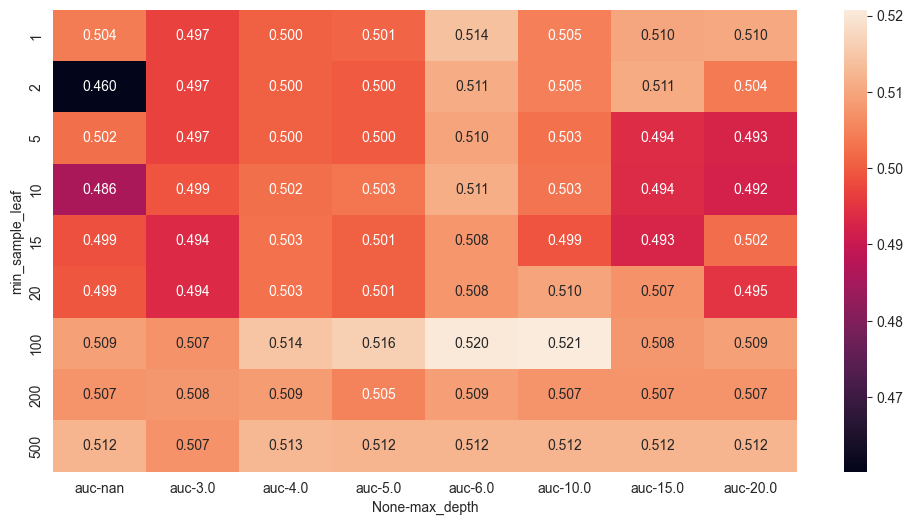

In [76]:
sns.heatmap(df_score_pivot, annot=True, fmt='.3f')

In [77]:
dt = DecisionTreeClassifier(max_depth=10, min_samples_leaf=20)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, min_samples_leaf=20)

In [78]:
rf = RandomForestClassifier(n_estimators=10, random_state=1)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=10, random_state=1)

In [79]:
y_pred = rf.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)

np.float64(0.5058564404176539)

In [80]:
scores = []

for n in range(10, 201, 10):
    rf = RandomForestClassifier(n_estimators=n, random_state=1)
    rf.fit(X_train, y_train)
    
    y_pred = rf.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)
    scores.append((n, auc))

In [81]:
df_scores = pd.DataFrame(scores, columns=['n_estimators', 'auc'])
df_scores.head()

,n_estimators,auc
0,10,0.505856
1,20,0.515226
2,30,0.512859
3,40,0.507179
4,50,0.510164


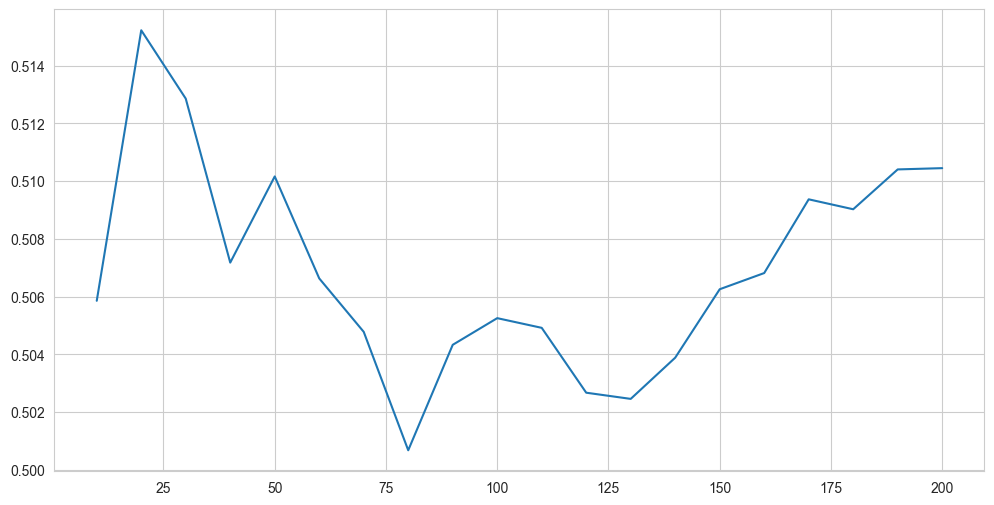

In [82]:
plt.plot(df_scores.n_estimators, df_scores.auc)

In [86]:
scores = []

for d in [20, 10, 15]:
    
    for n in range(10, 201, 10):
        rf = RandomForestClassifier(n_estimators=n, max_depth=d, random_state=1)
        rf.fit(X_train, y_train)
    
        y_pred = rf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
        scores.append((d, n, auc))

In [87]:
columns = ['max_depth', 'n_estimators', 'auc']
df_scores = pd.DataFrame(scores,columns=columns)
df_scores.head()

,max_depth,n_estimators,auc
0,20,10,0.508600
1,20,20,0.527721
2,20,30,0.522861
3,20,40,0.531103
4,20,50,0.525135


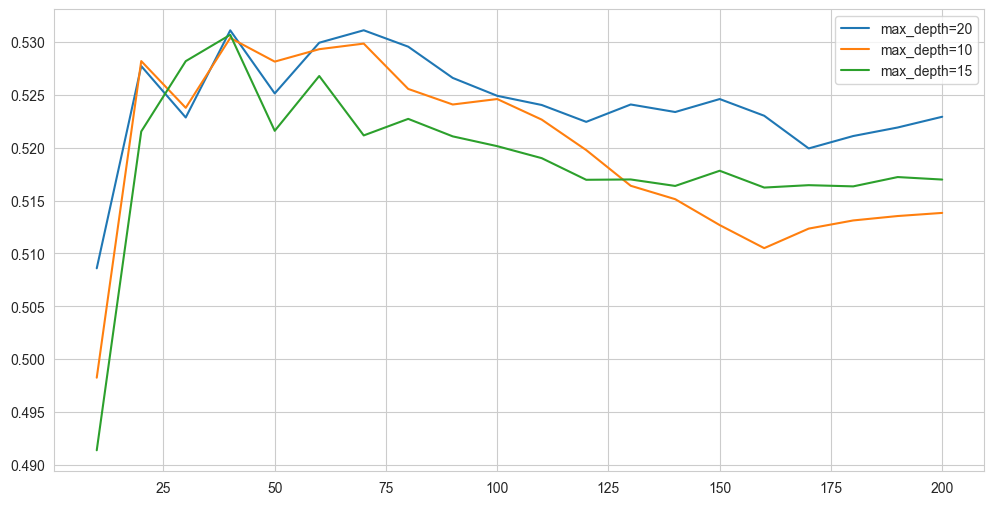

In [89]:
for d in [20, 10, 15]:
    df_subset = df_scores[df_scores.max_depth == d]
    plt.plot(df_subset.n_estimators, df_subset.auc, label='max_depth=%d' % d)
    
plt.legend()

In [90]:
max_depth = 20

In [91]:
scores = []

for s in [1, 3, 5, 10, 50]:
    
    for n in range(10, 201, 10):
        rf = RandomForestClassifier(n_estimators=n, max_depth=max_depth, min_samples_leaf=s, random_state=1)
        rf.fit(X_train, y_train)
    
        y_pred = rf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
        scores.append((s, n, auc))

In [92]:
columns = ['min_samples_leaf', 'n_estimators', 'auc']
df_scores = pd.DataFrame(scores,columns=columns)
df_scores.head()

,min_samples_leaf,n_estimators,auc
0,1,10,0.508600
1,1,20,0.527721
2,1,30,0.522861
3,1,40,0.531103
4,1,50,0.525135


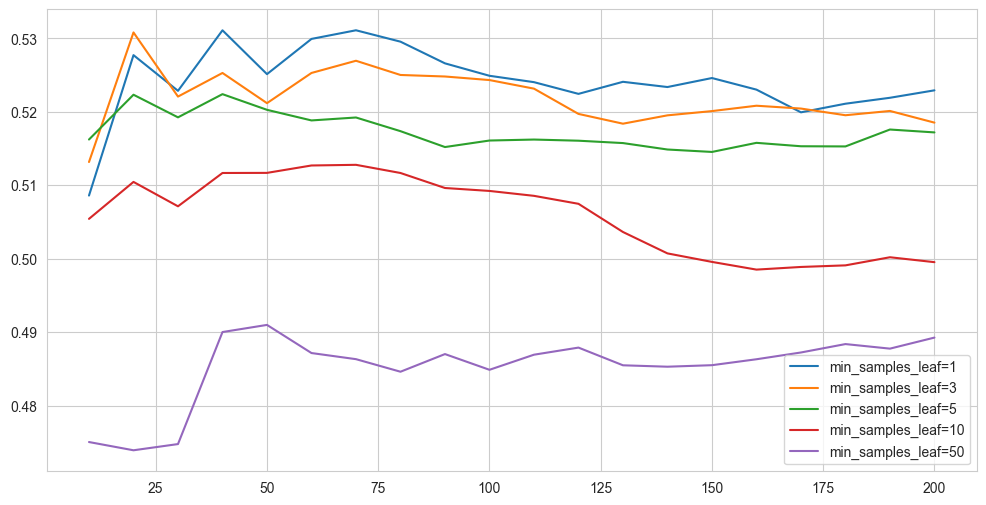

In [93]:
for s in [1, 3, 5, 10, 50]:
    df_subset = df_scores[df_scores.min_samples_leaf == s]
    plt.plot(df_subset.n_estimators, df_subset.auc, label='min_samples_leaf=%d' % s)
    
plt.legend()

In [94]:
min_samples_leaf = 3

In [95]:
rf = RandomForestClassifier(n_estimators=100, max_depth=max_depth, min_samples_leaf=min_samples_leaf, random_state=1, n_jobs=-1)
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=20, min_samples_leaf=3, n_jobs=-1,
                       random_state=1)